# 02 - Tiền Xử Lý Dữ Liệu và Mô Hình Hóa

## Mục lục các bước tiền xử lý dữ liệu

### 1. Tích hợp dữ liệu (Data Integration)
- Load dữ liệu từ nhiều nguồn
- Trong hệ thống: Load từ file CSV

### 2. Phân tích khám phá dữ liệu (EDA)
- Thống kê mô tả
- Phân phối các biến
- Ma trận tương quan
- Phân tích biến mục tiêu

### 3. Kiểm tra chất lượng dữ liệu (Data Quality)
- Missing values
- Giá trị không hợp lệ
- Outliers

### 4. Lấy mẫu (Sampling)
- Simple Random Sampling
- Stratified Sampling (Phân tầng)
- Sampling có/không có thay thế

### 5. Tạo mới thuộc tính đặc trưng (Feature Engineering)
- BMI_category (Rời rạc hóa)
- comorbidity_score
- healthy_lifestyle

### 6. Chuyển đổi thuộc tính (Attribute Transformation)
- StandardScaler cho biến liên tục
- OneHotEncoder cho biến phân loại

### 7. Lựa chọn thuộc tính đặc trưng (Feature Selection)
- SelectKBest với ANOVA F-test
- Mutual Information

### 8. Giảm số chiều (Dimensionality Reduction)
- PCA (Principal Component Analysis)

### 9. Xử lý mất cân bằng dữ liệu (Imbalanced Data)
- Class weights
- SMOTE (minh họa)

### 10. Cross-Validation và Huấn luyện mô hình
- K-Fold Cross Validation
- Training các mô hình
- Hyperparameter tuning

## 1. Import thư viện

In [53]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import json
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

print("Đã import tất cả thư viện thành công!")

Đã import tất cả thư viện thành công!


## 2. Load dữ liệu (Kỹ thuật Tích hợp)

In [54]:
from src.data.load_data import load_raw_data

df = load_raw_data()
print(f"Shape: {df.shape}")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột: {df.shape[1]}")
print(f"\nDanh sách các cột:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")
df.head()

Shape: (253680, 22)
Số dòng: 253,680
Số cột: 22

Danh sách các cột:
  1. Diabetes_binary
  2. HighBP
  3. HighChol
  4. CholCheck
  5. BMI
  6. Smoker
  7. Stroke
  8. HeartDiseaseorAttack
  9. PhysActivity
  10. Fruits
  11. Veggies
  12. HvyAlcoholConsump
  13. AnyHealthcare
  14. NoDocbcCost
  15. GenHlth
  16. MentHlth
  17. PhysHlth
  18. DiffWalk
  19. Sex
  20. Age
  21. Education
  22. Income


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Phân tích khám phá dữ liệu (EDA)

### 3.1. Thông tin tổng quan

In [55]:
print("="*60)
print("THÔNG TIN TỔNG QUAN VỀ DATASET")
print("="*60)

df.info()
print("\n" + "="*60)
print("THỐNG KÊ MÔ TẢ")
print("="*60)
df.describe().T

THÔNG TIN TỔNG QUAN VỀ DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth              

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### 3.2. Phân tích biến mục tiêu (Target Analysis)

PHÂN TÍCH BIẾN MỤC TIÊU

Phân phối target:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Tỷ lệ: 86.07% non-diabetic, 13.93% diabetic


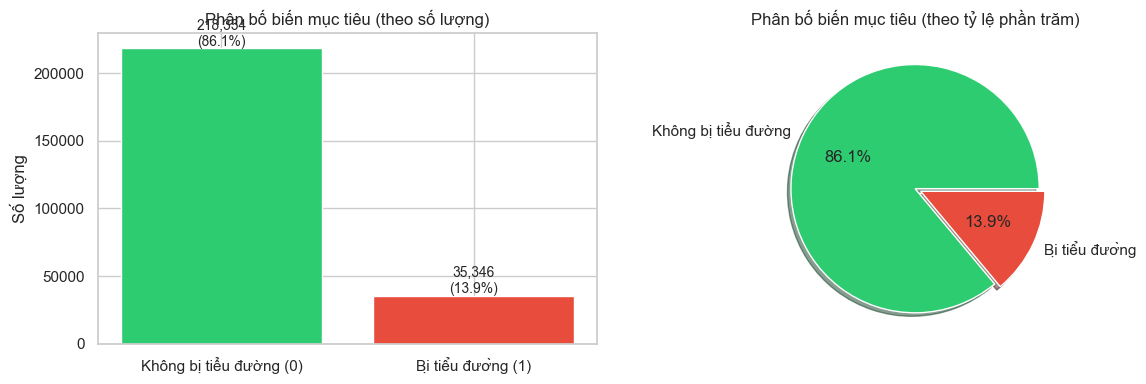

 NHẬN XÉT: Dữ liệu bị MẤT CÂN BẰNG NGHIÊM TRỌNG!
   - Tỷ lệ imbalance: 6.18:1


In [56]:
target_col = "Diabetes_binary"

print("PHÂN TÍCH BIẾN MỤC TIÊU")
print("="*50)

target_dist = df[target_col].value_counts().sort_index()
print("\nPhân phối target:")
print(target_dist)
print(f"\nTỷ lệ: {target_dist[0]/len(df)*100:.2f}% non-diabetic, {target_dist[1]/len(df)*100:.2f}% diabetic")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Không bị tiểu đường (0)', 'Bị tiểu đường (1)'], target_dist.values, color=colors)
axes[0].set_title('Phân bố biến mục tiêu (theo số lượng)', fontsize=12)
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(target_dist.values):
    axes[0].text(i, v + 2000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_dist.values, labels=['Không bị tiểu đường', 'Bị tiểu đường'], autopct='%1.1f%%', 
            colors=colors, explode=(0, 0.05), shadow=True)
axes[1].set_title('Phân bố biến mục tiêu (theo tỷ lệ phần trăm)', fontsize=12)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "target_distribution.png", dpi=150)
plt.show()

print(" NHẬN XÉT: Dữ liệu bị MẤT CÂN BẰNG NGHIÊM TRỌNG!")
print(f"   - Tỷ lệ imbalance: {target_dist[0]/target_dist[1]:.2f}:1")

### 3.3. Phân phối các biến số (Feature Distributions)

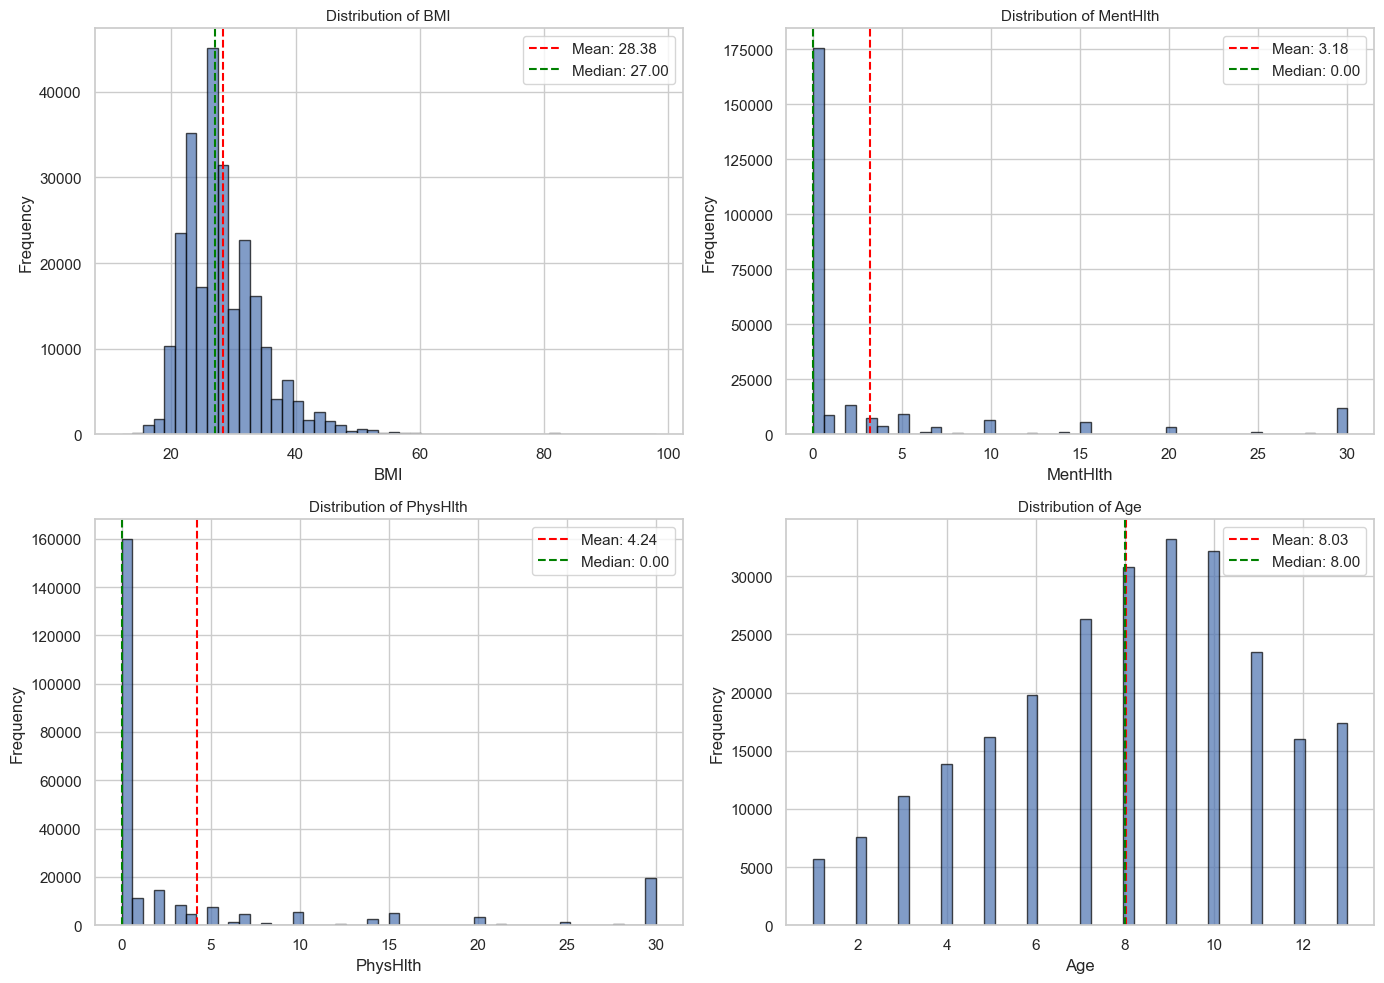

In [57]:
# Các biến liên tục
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[i].legend()

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "continuous_features_distribution.png", dpi=150)
plt.show()

### 3.4. Ma trận tương quan (Correlation Matrix)

CORRELATION VỚI BIẾN MỤC TIÊU (Diabetes_binary):
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919


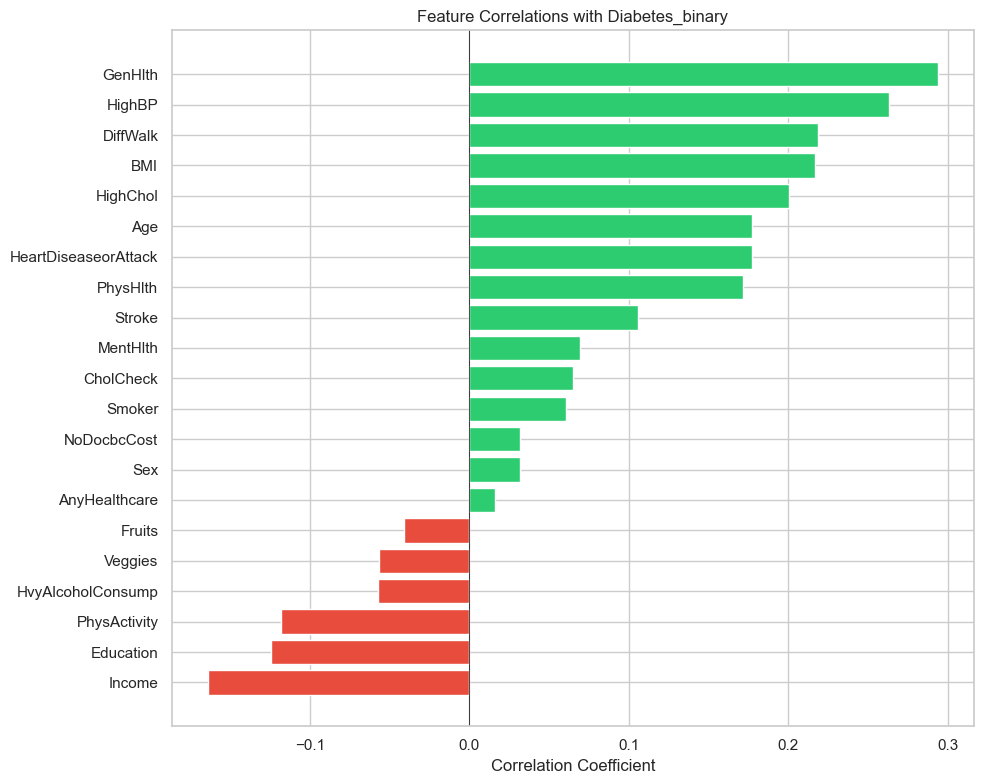

In [58]:
# Tính correlation với target
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)

print("CORRELATION VỚI BIẾN MỤC TIÊU (Diabetes_binary):")
print("="*50)
print(correlations.to_string())

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
corr_with_target = correlations.sort_values()
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_target]
plt.barh(corr_with_target.index, corr_with_target.values, color=colors)
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlations with Diabetes_binary', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "correlation_with_target.png", dpi=150)
plt.show()

### 3.5. Ma trận tương quan giữa các features

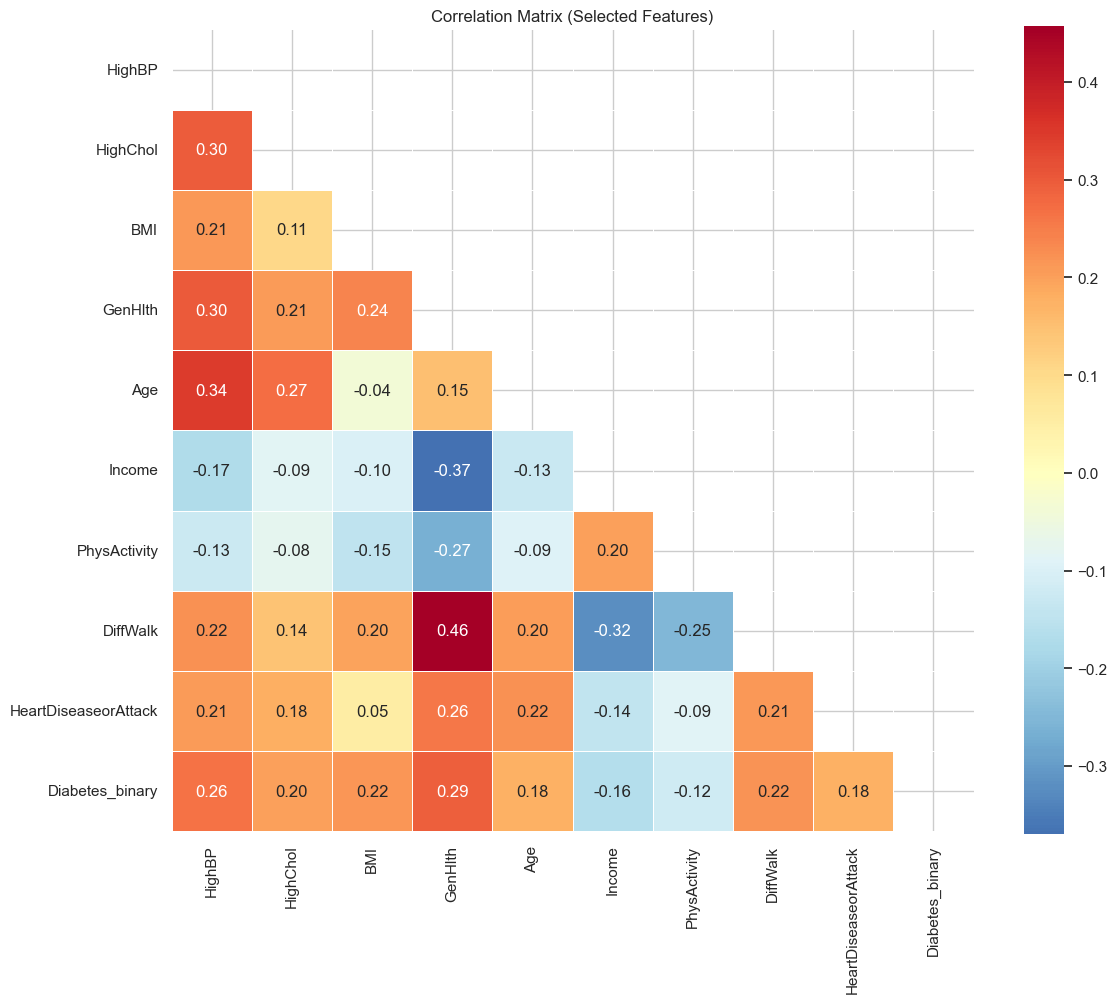

In [59]:
# Chọn các features quan trọng để vẽ heatmap
important_features = ['HighBP', 'HighChol', 'BMI', 'GenHlth', 'Age', 'Income', 
                      'PhysActivity', 'DiffWalk', 'HeartDiseaseorAttack']

plt.figure(figsize=(12, 10))
corr_matrix = df[important_features + [target_col]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix (Selected Features)', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "correlation_matrix.png", dpi=150)
plt.show()

## 4. Kiểm tra chất lượng dữ liệu (Data Quality)

### 4.1. Kiểm tra Missing Values

In [60]:
print("KIỂM TRA MISSING VALUES")
print("="*50)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})

if missing.sum() == 0:
    print("Dữ liệu sạch, không có missing values!")
else:
    print("Có missing values:")
    display(missing_df[missing_df['Missing Count'] > 0])

KIỂM TRA MISSING VALUES
Dữ liệu sạch, không có missing values!


### 4.2. Kiểm tra giá trị không hợp lệ

In [61]:
print("KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ")
print("="*50)

binary_cols = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]

ordinal_ranges = {"GenHlth": (1, 5), "Age": (1, 13), "Education": (1, 6), "Income": (1, 8)}

invalid_count = 0

for col in binary_cols:
    invalid = sorted(set(df[col].dropna().unique()) - {0, 1, 0.0, 1.0})
    if invalid:
        print(f"  {col}: giá trị không hợp lệ {invalid}")
        invalid_count += 1

for col, (mn, mx) in ordinal_ranges.items():
    cnt = (~df[col].between(mn, mx)).sum()
    if cnt > 0:
        print(f"  {col}: {cnt} giá trị không hợp lệ (phải nằm trong [{mn}, {mx}])")
        invalid_count += 1

if invalid_count == 0:
    print(" Không có giá trị không hợp lệ!")

KIỂM TRA GIÁ TRỊ KHÔNG HỢP LỆ
 Không có giá trị không hợp lệ!


### 4.3. Phân tích Outliers

PHÂN TÍCH OUTLIERS (IQR Method)


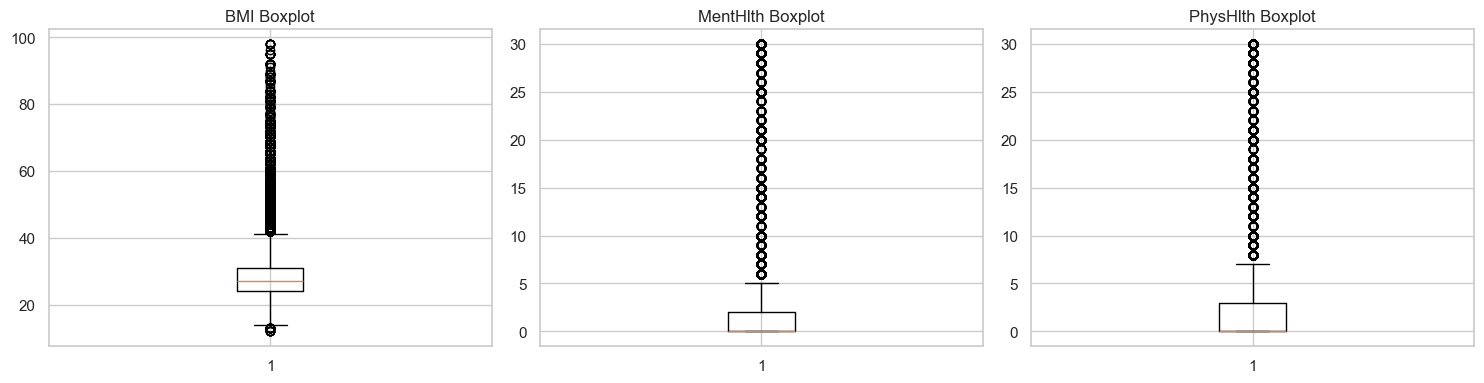

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier %
0,BMI,24.0,31.0,7.0,13.5,41.5,9847,3.88%
1,MentHlth,0.0,2.0,2.0,-3.0,5.0,36208,14.27%
2,PhysHlth,0.0,3.0,3.0,-4.5,7.5,40949,16.14%


In [62]:
print("PHÂN TÍCH OUTLIERS (IQR Method)")
print("="*50)

outlier_cols = ['BMI', 'MentHlth', 'PhysHlth']
outlier_summary = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(outlier_cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = outliers / len(df) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outliers': outliers,
        'Outlier %': f'{outlier_pct:.2f}%'
    })
    
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "outliers_boxplot.png", dpi=150)
plt.show()

display(pd.DataFrame(outlier_summary))

### 4.4. Tổng hợp chất lượng dữ liệu

In [63]:
print("TONG HOP CHAT LUONG DU LIEU")
print("="*50)

# Tinh outliers bang IQR method
outlier_cols = ['BMI', 'MentHlth', 'PhysHlth']
outlier_counts = {}

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = outliers

quality_summary = {
    'Metric': [
        'Tong so dong',
        'Tong so cot',
        'Missing values',
        'Gia tri khong hop le (binary)',
        'Gia tri khong hop le (ordinal)',
        'Outliers (BMI) - IQR',
        'Outliers (MentHlth) - IQR',
        'Outliers (PhysHlth) - IQR',
        'Imbalance ratio'
    ],
    'Value': [
        f'{len(df):,}',
        f'{df.shape[1]}',
        f'{df.isnull().sum().sum()}',
        '0',
        '0',
        f'{outlier_counts["BMI"]:,}',
        f'{outlier_counts["MentHlth"]:,}',
        f'{outlier_counts["PhysHlth"]:,}',
        f'{df[target_col].value_counts()[0] / df[target_col].value_counts()[1]:.2f}:1'
    ],
    'Status': [
        'OK',
        'OK',
        'OK',
        'OK',
        'OK',
        'Can xu ly',  # BMI - du co outliers nhung giu nguyen gia tri
        'Can xu ly',
        'Can xu ly',
        'Mat can bang'
    ]
}

display(pd.DataFrame(quality_summary))


TONG HOP CHAT LUONG DU LIEU


,Metric,Value,Status
0,Tong so dong,"253,680",OK
1,Tong so cot,22,OK
2,Missing values,0,OK
3,Gia tri khong hop le (binary),0,OK
4,Gia tri khong hop le (ordinal),0,OK
5,Outliers (BMI) - IQR,"9,847",Can xu ly
6,Outliers (MentHlth) - IQR,"36,208",Can xu ly
7,Outliers (PhysHlth) - IQR,"40,949",Can xu ly
8,Imbalance ratio,6.18:1,Mat can bang


## 5. Kỹ thuật Lấy mẫu (Sampling)

### 5.1. Giới thiệu các phương pháp lấy mẫu

In [64]:
print("""
KỸ THUẬT LẤY MẪU (SAMPLING)
===========================

1. Simple Random Sampling (Lấy mẫu ngẫu nhiên đơn giản)
   - Mỗi phần tử có xác suất được chọn như nhau
   - Không đảm bảo tỷ lệ lớp giữ nguyên

2. Stratified Sampling (Lấy mẫu phân tầng) - ĐANG SỬ DỤNG
   - Chia dữ liệu thành nhiều phần vùng (strata) theo biến mục tiêu
   - Rút ra mẫu ngẫu nhiên từ mỗi phần vùng
   - Đảm bảo tỷ lệ lớp giống nhau trong train/test

3. Systematic Sampling (Lấy mẫu hệ thống)
   - Chọn phần tử cách đều nhau

4. Cluster Sampling (Lấy mẫu cụm)
   - Chia thành cụm, chọn ngẫu nhiên cụm
""")


KỸ THUẬT LẤY MẪU (SAMPLING)

1. Simple Random Sampling (Lấy mẫu ngẫu nhiên đơn giản)
   - Mỗi phần tử có xác suất được chọn như nhau
   - Không đảm bảo tỷ lệ lớp giữ nguyên

2. Stratified Sampling (Lấy mẫu phân tầng) - ĐANG SỬ DỤNG
   - Chia dữ liệu thành nhiều phần vùng (strata) theo biến mục tiêu
   - Rút ra mẫu ngẫu nhiên từ mỗi phần vùng
   - Đảm bảo tỷ lệ lớp giống nhau trong train/test

3. Systematic Sampling (Lấy mẫu hệ thống)
   - Chọn phần tử cách đều nhau

4. Cluster Sampling (Lấy mẫu cụm)
   - Chia thành cụm, chọn ngẫu nhiên cụm



### 5.2. So sánh Random vs Stratified Sampling

In [65]:
# Simple Random Sampling (không stratify)
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    df.drop(columns=[target_col]),
    df[target_col],
    test_size=0.2,
    random_state=42
)  # Không có stratify

# Stratified Sampling (có stratify)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[target_col]),
    df[target_col],
    test_size=0.2,
    random_state=42,
    stratify=df[target_col]
)

print("SO SÁNH RANDOM vs STRATIFIED SAMPLING")
print("="*60)
print(f"{'Metric':<30} {'Random':<15} {'Stratified':<15}")
print("-"*60)
print(f"{'Train size':<30} {len(y_train_random):<15} {len(y_train):<15}")
print(f"{'Test size':<30} {len(y_test_random):<15} {len(y_test):<15}")
print(f"{'Train diabetic ratio':<30} {y_train_random.mean():.4f}       {y_train.mean():.4f}")
print(f"{'Test diabetic ratio':<30} {y_test_random.mean():.4f}       {y_test.mean():.4f}")

print("\n✅ KẾT LUẬN: Stratified Sampling đảm bảo tỷ lệ lớp nhất quán hơn.")

SO SÁNH RANDOM vs STRATIFIED SAMPLING
Metric                         Random          Stratified     
------------------------------------------------------------
Train size                     202944          202944         
Test size                      50736           50736          
Train diabetic ratio           0.1397       0.1393
Test diabetic ratio            0.1379       0.1393

✅ KẾT LUẬN: Stratified Sampling đảm bảo tỷ lệ lớp nhất quán hơn.


## 6. Tạo mới thuộc tính đặc trưng (Feature Engineering)

### 6.1. Giới thiệu

In [66]:
print("""
TẠO MỚI THUỘC TÍNH ĐẶC TRƯNG (FEATURE ENGINEERING)
=================================================

Mục đích: Tạo các feature mới từ các feature gốc để:
1. Tăng khả năng dự báo của mô hình
2. Giảm phức tạp của dữ liệu
3. Giúp mô hình dễ giải thích hơn

Các feature mới trong hệ thống:
- BMI_category: Rời rạc hóa BMI thành các nhóm (thiếu cân, bình thường, thừa cân, béo phì)
- comorbidity_score: Tổng hợp các tình trạng bệnh lý đi kèm
- healthy_lifestyle: Điểm lối sống lành mạnh
""")


TẠO MỚI THUỘC TÍNH ĐẶC TRƯNG (FEATURE ENGINEERING)

Mục đích: Tạo các feature mới từ các feature gốc để:
1. Tăng khả năng dự báo của mô hình
2. Giảm phức tạp của dữ liệu
3. Giúp mô hình dễ giải thích hơn

Các feature mới trong hệ thống:
- BMI_category: Rời rạc hóa BMI thành các nhóm (thiếu cân, bình thường, thừa cân, béo phì)
- comorbidity_score: Tổng hợp các tình trạng bệnh lý đi kèm
- healthy_lifestyle: Điểm lối sống lành mạnh



### 6.2. Tạo BMI_category (Rời rạc hóa BMI)

BMI Category Distribution:
  thiếu cân: 3,127 (1.2%)
  bình thường: 86,099 (33.9%)
  thừa cân: 91,176 (35.9%)
  béo phì: 73,278 (28.9%)


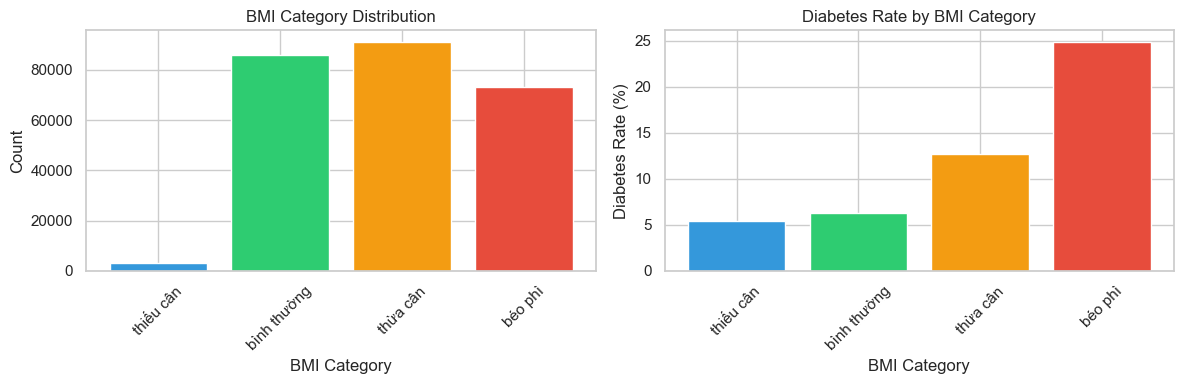

In [67]:
# BMI_category: Phân nhóm BMI theo chuẩn WHO
df["BMI_category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["thiếu cân", "bình thường", "thừa cân", "béo phì"],
    include_lowest=True
)

print("BMI Category Distribution:")
print("="*40)
bmi_dist = df["BMI_category"].value_counts().sort_index()
for cat, count in bmi_dist.items():
    print(f"  {cat}: {count:,} ({count/len(df)*100:.1f}%)")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(bmi_dist.index.astype(str), bmi_dist.values, color=colors)
axes[0].set_title('BMI Category Distribution')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# BMI vs Diabetes
bmi_diabetes = df.groupby('BMI_category')[target_col].mean().sort_index()
axes[1].bar(bmi_diabetes.index.astype(str), bmi_diabetes.values * 100, color=colors)
axes[1].set_title('Diabetes Rate by BMI Category')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "bmi_category_distribution.png", dpi=150)
plt.show()

### 6.3. Tạo comorbidity_score (Tích hợp các thuộc tính)

Comorbidity Score (Tích hợp 5 thuộc tính bệnh lý)
Các thuộc tính được tích hợp: ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack', 'DiffWalk']
Điểm trung bình: 1.16
Điểm min: 0.0, max: 5.0


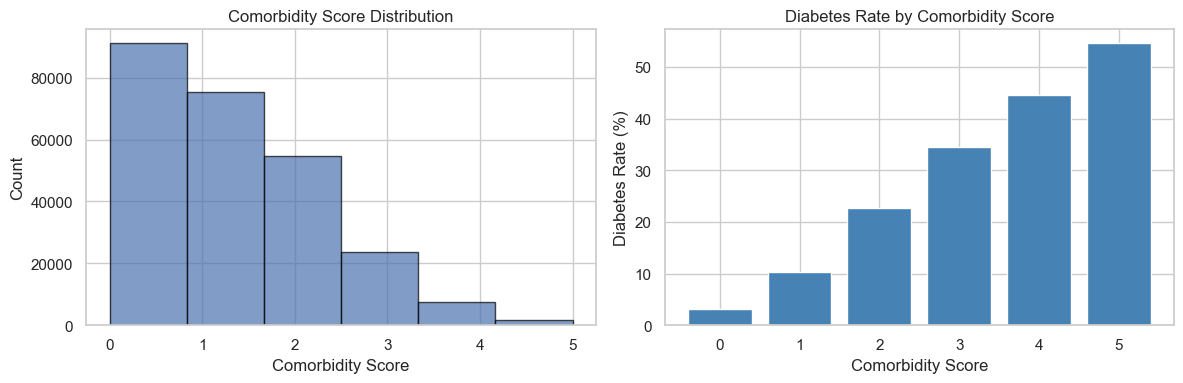

In [68]:
# comorbidity_score: Tổng hợp các tình trạng bệnh lý
# Kỹ thuật TÍCH HỢP: Kết hợp nhiều thuộc tính thành một
comorbidity_cols = ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack", "DiffWalk"]
df["comorbidity_score"] = df[comorbidity_cols].sum(axis=1)

print("Comorbidity Score (Tích hợp 5 thuộc tính bệnh lý)")
print("="*50)
print(f"Các thuộc tính được tích hợp: {comorbidity_cols}")
print(f"Điểm trung bình: {df['comorbidity_score'].mean():.2f}")
print(f"Điểm min: {df['comorbidity_score'].min()}, max: {df['comorbidity_score'].max()}")

# Vẽ phân phối
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["comorbidity_score"], bins=6, edgecolor='black', alpha=0.7)
axes[0].set_title('Comorbidity Score Distribution')
axes[0].set_xlabel('Comorbidity Score')
axes[0].set_ylabel('Count')

# Comorbidity vs Diabetes
comorb_diabetes = df.groupby('comorbidity_score')[target_col].mean() * 100
axes[1].bar(comorb_diabetes.index, comorb_diabetes.values, color='steelblue')
axes[1].set_title('Diabetes Rate by Comorbidity Score')
axes[1].set_xlabel('Comorbidity Score')
axes[1].set_ylabel('Diabetes Rate (%)')

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "comorbidity_score_distribution.png", dpi=150)
plt.show()

### 6.4. Tạo healthy_lifestyle

Healthy Lifestyle Score
Các yếu tố: PhysActivity, Fruits, Veggies, Non-Smoker, Non-Alcohol
Điểm trung bình: 3.70
Điểm min: 0.0, max: 5.0


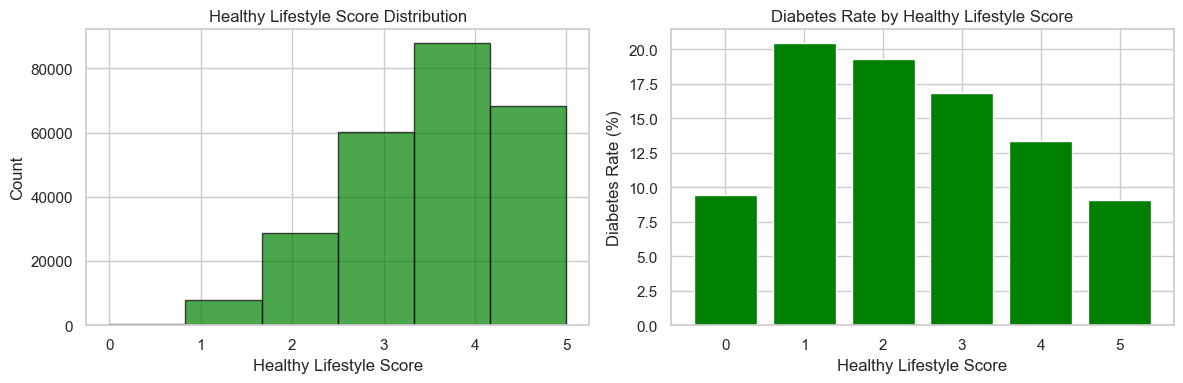

In [69]:
# healthy_lifestyle: Điểm lối sống lành mạnh
df["healthy_lifestyle"] = (
    df["PhysActivity"]
    + df["Fruits"]
    + df["Veggies"]
    + (1 - df["Smoker"])
    + (1 - df["HvyAlcoholConsump"])
)

print("Healthy Lifestyle Score")
print("="*50)
print(f"Các yếu tố: PhysActivity, Fruits, Veggies, Non-Smoker, Non-Alcohol")
print(f"Điểm trung bình: {df['healthy_lifestyle'].mean():.2f}")
print(f"Điểm min: {df['healthy_lifestyle'].min()}, max: {df['healthy_lifestyle'].max()}")

# Vẽ phân phối
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["healthy_lifestyle"], bins=6, edgecolor='black', alpha=0.7, color='green')
axes[0].set_title('Healthy Lifestyle Score Distribution')
axes[0].set_xlabel('Healthy Lifestyle Score')
axes[0].set_ylabel('Count')

# Lifestyle vs Diabetes
lifestyle_diabetes = df.groupby('healthy_lifestyle')[target_col].mean() * 100
axes[1].bar(lifestyle_diabetes.index, lifestyle_diabetes.values, color='green')
axes[1].set_title('Diabetes Rate by Healthy Lifestyle Score')
axes[1].set_xlabel('Healthy Lifestyle Score')
axes[1].set_ylabel('Diabetes Rate (%)')

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "healthy_lifestyle_distribution.png", dpi=150)
plt.show()

### 6.5. Kiểm tra tương quan của feature mới với target

In [70]:
# Tính correlation của feature mới với target
df["BMI_category_encoded"] = df["BMI_category"].cat.codes

new_correlations = {
    "comorbidity_score": df["comorbidity_score"].corr(df[target_col]),
    "healthy_lifestyle": df["healthy_lifestyle"].corr(df[target_col]),
    "BMI_category_encoded": df["BMI_category_encoded"].corr(df[target_col])
}

print("CORRELATION VỚI Diabetes_binary:")
print("="*50)
for feat, corr in sorted(new_correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = "↑" if corr > 0 else "↓"
    print(f"  {feat}: {corr:.4f} {direction}")

print("\n✅ NHẬN XÉT:")
print("   - comorbidity_score có tương quan dương mạnh với diabetes")
print("   - healthy_lifestyle có tương quan âm (bảo vệ khỏi diabetes)")
print("   - BMI_category cũng có tương quan dương")

CORRELATION VỚI Diabetes_binary:
  comorbidity_score: 0.3380 ↑
  BMI_category_encoded: 0.2107 ↑
  healthy_lifestyle: -0.1006 ↓

✅ NHẬN XÉT:
   - comorbidity_score có tương quan dương mạnh với diabetes
   - healthy_lifestyle có tương quan âm (bảo vệ khỏi diabetes)
   - BMI_category cũng có tương quan dương


## 7. Chuyển đổi thuộc tính (Attribute Transformation)

### 7.1. Giới thiệu

In [71]:
print("""
CHUYỂN ĐỔI THUỘC TÍNH (ATTRIBUTE TRANSFORMATION)
==============================================

1. StandardScaler: Chuẩn hóa về phân phối chuẩn (mean=0, std=1)
   - Phù hợp cho Logistic Regression
   - Các biến: BMI, MentHlth, PhysHlth, Age, comorbidity_score, healthy_lifestyle

2. OneHotEncoder: Mã hóa one-hot cho biến phân loại
   - Biến: BMI_category (4 giá trị)

3. Binary encoding: Giữ nguyên cho biến binary (0/1)
""")


CHUYỂN ĐỔI THUỘC TÍNH (ATTRIBUTE TRANSFORMATION)

1. StandardScaler: Chuẩn hóa về phân phối chuẩn (mean=0, std=1)
   - Phù hợp cho Logistic Regression
   - Các biến: BMI, MentHlth, PhysHlth, Age, comorbidity_score, healthy_lifestyle

2. OneHotEncoder: Mã hóa one-hot cho biến phân loại
   - Biến: BMI_category (4 giá trị)

3. Binary encoding: Giữ nguyên cho biến binary (0/1)



### 7.2. Xác định các nhóm biến

In [72]:
# Các biến cần scale
continuous_cols_to_scale = ["BMI", "MentHlth", "PhysHlth", "Age", "comorbidity_score", "healthy_lifestyle"]

# Các biến categorical cần encode
categorical_cols = ["BMI_category"]

# Các biến binary (0/1, không cần scale)
binary_cols = ["HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex",
    "GenHlth", "Education", "Income"]

print("PHÂN LOẠI BIẾN:")
print("="*50)
print(f"Số biến cần scale: {len(continuous_cols_to_scale)}")
print(f"  → {continuous_cols_to_scale}")
print(f"\nSố biến categorical: {len(categorical_cols)}")
print(f"  → {categorical_cols}")
print(f"\nSố biến binary: {len(binary_cols)}")
print(f"  → {binary_cols}")

PHÂN LOẠI BIẾN:
Số biến cần scale: 6
  → ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'comorbidity_score', 'healthy_lifestyle']

Số biến categorical: 1
  → ['BMI_category']

Số biến binary: 17
  → ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'GenHlth', 'Education', 'Income']


### 7.3. Tạo Preprocessor

In [73]:
# Chuẩn bị X, y
X = df.drop(columns=[target_col, "BMI_category_encoded"])
y = df[target_col].astype(int)
feature_columns = X.columns.tolist()

# Chỉ lấy cột cần thiết cho X_train/X_test
X_train_fe = X.loc[X_train.index].copy()
X_test_fe = X.loc[X_test.index].copy()

# Tạo ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous_scaler", StandardScaler(), continuous_cols_to_scale),
        ("category_encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
)

print("Preprocessor đã được cấu hình.")
print("="*50)
print(f"Scale: {continuous_cols_to_scale}")
print(f"Encode: {categorical_cols}")

Preprocessor đã được cấu hình.
Scale: ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'comorbidity_score', 'healthy_lifestyle']
Encode: ['BMI_category']


### 7.4. So sánh kích thước trước và sau tiền xử lý

In [74]:
# So sánh kích thước dataset gốc và dataset sau tiền xử lý
raw_data_path = ROOT / "data" / "raw" / "diabetes_binary_health_indicators_BRFSS2015.csv"
raw_shape = pd.read_csv(raw_data_path).shape
engineered_shape = df.drop(columns=["BMI_category_encoded"]).shape

comparison_df = pd.DataFrame({
    "Giai đoạn": [
        "Dataset gốc",
        "Sau feature engineering",
        "X_train sau tiền xử lý",
        "X_test sau tiền xử lý",
        "y_train",
        "y_test"
    ],
    "Số dòng": [
        raw_shape[0],
        engineered_shape[0],
        X_train_fe.shape[0],
        X_test_fe.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ],
    "Số cột": [
        raw_shape[1],
        engineered_shape[1],
        X_train_fe.shape[1],
        X_test_fe.shape[1],
        1,
        1
    ]
})

display(comparison_df)

print(f"\nTổng số dòng sau khi chia train/test: {X_train_fe.shape[0] + X_test_fe.shape[0]:,}")
print(f"Tỷ lệ train: {X_train_fe.shape[0] / raw_shape[0] * 100:.2f}%")
print(f"Tỷ lệ test: {X_test_fe.shape[0] / raw_shape[0] * 100:.2f}%")

,Giai đoạn,Số dòng,Số cột
0,Dataset gốc,253680,22
1,Sau feature engineering,253680,25
2,X_train sau tiền xử lý,202944,24
3,X_test sau tiền xử lý,50736,24
4,y_train,202944,1
5,y_test,50736,1



Tổng số dòng sau khi chia train/test: 253,680
Tỷ lệ train: 80.00%
Tỷ lệ test: 20.00%


## 8. Lựa chọn thuộc tính đặc trưng (Feature Selection)

### 8.1. Giới thiệu

In [75]:
print("""
LỰA CHỌN THUỘC TÍNH ĐẶC TRƯNG (FEATURE SELECTION)
==================================================

Mục đích: Loại bỏ feature yếu, giảm overfitting, tăng hiệu suất

Phương pháp:
1. SelectKBest: Chọn k feature tốt nhất theo scoring function
2. ANOVA F-test: Đánh giá mối quan hệ tuyến tính giữa feature và target
3. Mutual Information: Đo phụ thuộc lẫn nhau giữa feature và target
""")


LỰA CHỌN THUỘC TÍNH ĐẶC TRƯNG (FEATURE SELECTION)

Mục đích: Loại bỏ feature yếu, giảm overfitting, tăng hiệu suất

Phương pháp:
1. SelectKBest: Chọn k feature tốt nhất theo scoring function
2. ANOVA F-test: Đánh giá mối quan hệ tuyến tính giữa feature và target
3. Mutual Information: Đo phụ thuộc lẫn nhau giữa feature và target



### 8.2. Chi so F (ANOVA F-score)

In [76]:
# Fit preprocessor
X_train_scaled = preprocessor.fit_transform(X_train_fe)
X_test_scaled = preprocessor.transform(X_test_fe)

# Lấy feature names sau transform
temp_feature_names = preprocessor.get_feature_names_out()
temp_feature_names = [
    name.replace("continuous_scaler__", "").replace("category_encoder__", "").replace("remainder__", "")
    for name in temp_feature_names
]

# SelectKBest với ANOVA F-test
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_train_scaled, y_train)

# Điểm F của mỗi feature
feature_scores = pd.DataFrame({
    "feature": temp_feature_names,
    "f_score": selector_f.scores_,
    "p_value": selector_f.pvalues_
}).sort_values("f_score", ascending=False)

print("Top 15 features theo ANOVA F-score:")
print("="*50)
print(feature_scores.head(15).to_string(index=False))

Top 15 features theo ANOVA F-score:
                 feature      f_score  p_value
       comorbidity_score 26371.224767      0.0
                 GenHlth 19188.212049      0.0
                  HighBP 15131.268928      0.0
                DiffWalk 10304.406864      0.0
                     BMI 10242.564888      0.0
    BMI_category_béo phì  8843.909696      0.0
                HighChol  8519.724925      0.0
    HeartDiseaseorAttack  6640.418629      0.0
                     Age  6579.955654      0.0
                PhysHlth  6199.232633      0.0
                  Income  5622.537735      0.0
BMI_category_bình thường  5289.415381      0.0
               Education  3152.624326      0.0
            PhysActivity  2861.844249      0.0
                  Stroke  2320.802415      0.0


### 8.3. Vẽ biểu đồ Feature Scores

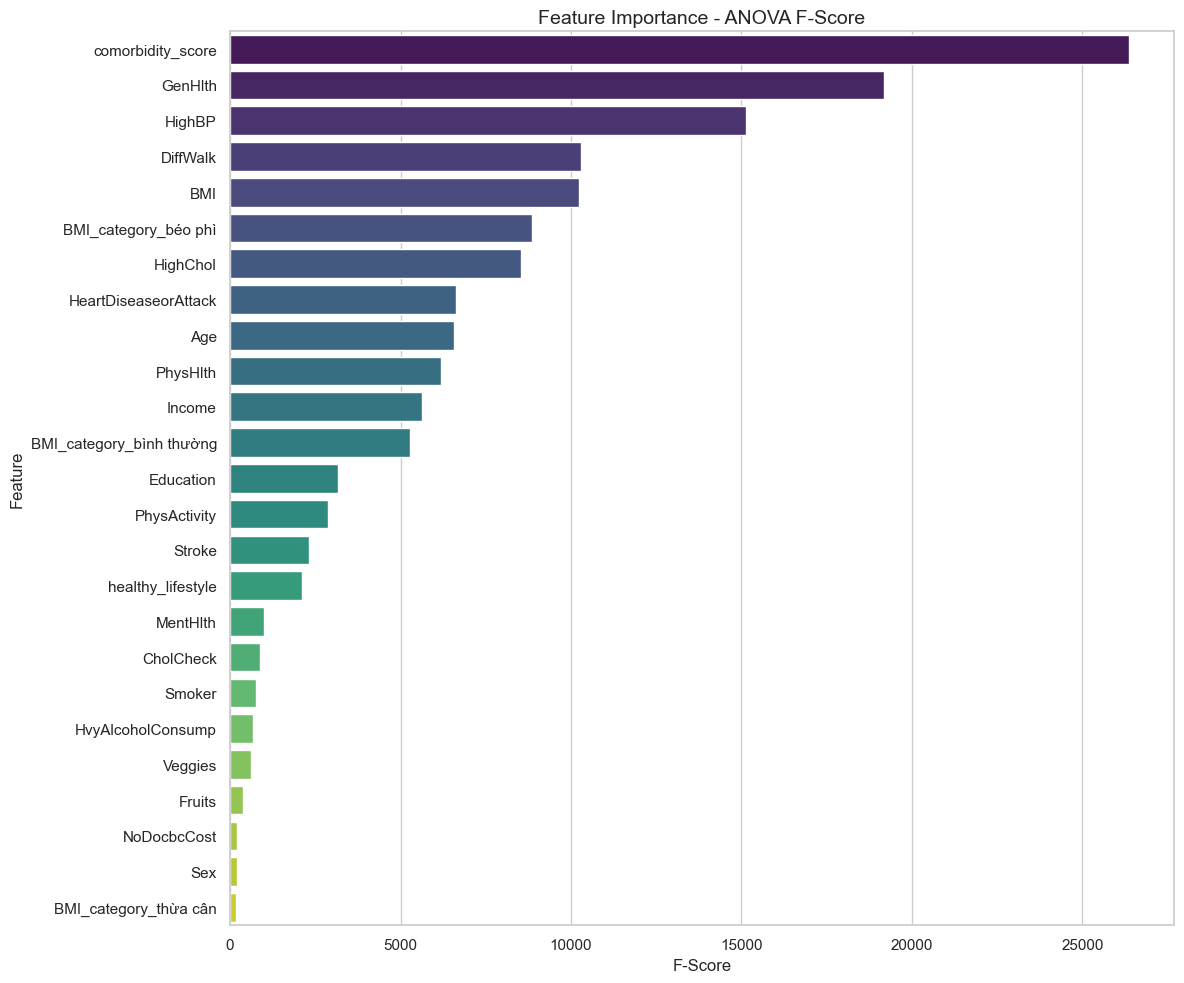

In [77]:
plt.figure(figsize=(12, 10))
top_n = 25
top_features = feature_scores.head(top_n)
sns.barplot(data=top_features, x="f_score", y="feature", palette="viridis")
plt.title("Feature Importance - ANOVA F-Score", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "feature_selection_fscore.png", dpi=150)
plt.show()

### 8.4. Mutual Information

In [78]:
# Mutual Information
mi_score_func = lambda X, y: mutual_info_classif(X, y, random_state=42)
selector_mi = SelectKBest(score_func=mi_score_func, k='all')
selector_mi.fit(X_train_scaled, y_train)

mi_scores = pd.DataFrame({
    "feature": temp_feature_names,
    "mi_score": selector_mi.scores_
}).sort_values("mi_score", ascending=False)

print("Top 15 features theo Mutual Information:")
print("="*50)
print(mi_scores.head(15).to_string(index=False))

Top 15 features theo Mutual Information:
                 feature  mi_score
       comorbidity_score  0.064681
                 GenHlth  0.051511
                  HighBP  0.051324
            PhysActivity  0.041408
           AnyHealthcare  0.041015
               CholCheck  0.038618
                HighChol  0.037089
                  Fruits  0.033257
                 Veggies  0.033193
                     BMI  0.029323
BMI_category_bình thường  0.028925
    BMI_category_béo phì  0.025555
                     Age  0.023606
                DiffWalk  0.022603
                  Smoker  0.020598


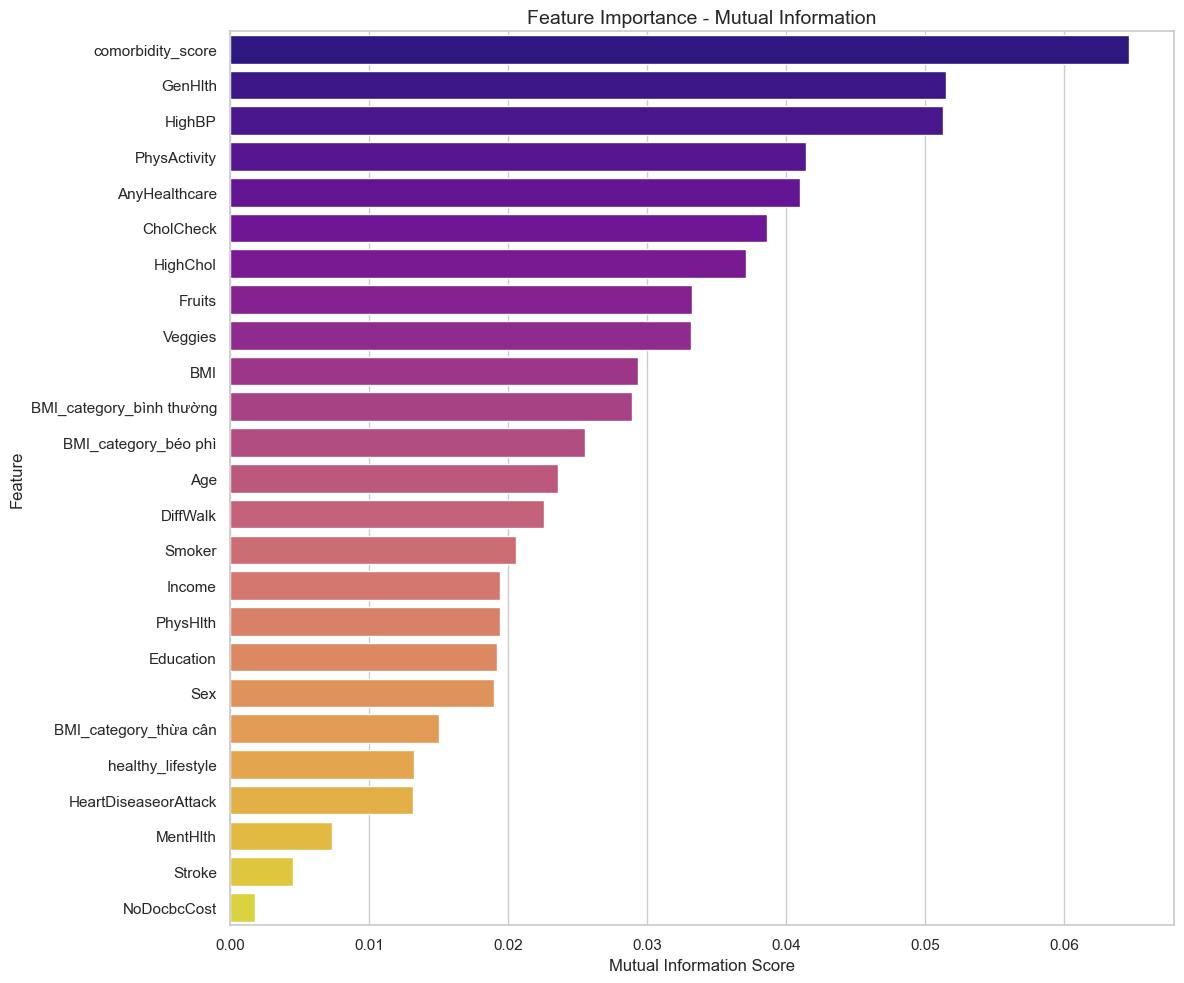

In [79]:
plt.figure(figsize=(12, 10))
top_mi = mi_scores.head(top_n)
sns.barplot(data=top_mi, x="mi_score", y="feature", palette="plasma")
plt.title("Feature Importance - Mutual Information", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "feature_selection_mi.png", dpi=150)
plt.show()

### 8.5. So sánh F-score và MI

In [80]:
# Merge hai phương pháp
feature_comparison = feature_scores.merge(mi_scores, on="feature")
feature_comparison = feature_comparison.sort_values("f_score", ascending=False)

print("So sánh F-score và Mutual Information (top 15):")
print("="*60)
print(feature_comparison.head(15).to_string(index=False))

So sánh F-score và Mutual Information (top 15):
                 feature      f_score  p_value  mi_score
       comorbidity_score 26371.224767      0.0  0.064681
                 GenHlth 19188.212049      0.0  0.051511
                  HighBP 15131.268928      0.0  0.051324
                DiffWalk 10304.406864      0.0  0.022603
                     BMI 10242.564888      0.0  0.029323
    BMI_category_béo phì  8843.909696      0.0  0.025555
                HighChol  8519.724925      0.0  0.037089
    HeartDiseaseorAttack  6640.418629      0.0  0.013192
                     Age  6579.955654      0.0  0.023606
                PhysHlth  6199.232633      0.0  0.019441
                  Income  5622.537735      0.0  0.019444
BMI_category_bình thường  5289.415381      0.0  0.028925
               Education  3152.624326      0.0  0.019187
            PhysActivity  2861.844249      0.0  0.041408
                  Stroke  2320.802415      0.0  0.004523


## 9. Giảm số chiều (Dimensionality Reduction)

### 9.1. Giới thiệu PCA

In [81]:
print("""
GIẢM SỐ CHIỀU (DIMENSIONALITY REDUCTION)
======================================

PCA (Principal Component Analysis):
- Tìm các thành phần chính (principal components)
- Các thành phần chính vuông góc (orthogonal) với nhau
- PC1 giải thích nhiều phương sai nhất
- PC2 giải thích phương sai còn lại

Lợi ích:
- Giảm số chiều dữ liệu
- Loại bỏ noise
- Tăng tốc độ training
- Giảm overfitting
""")


GIẢM SỐ CHIỀU (DIMENSIONALITY REDUCTION)

PCA (Principal Component Analysis):
- Tìm các thành phần chính (principal components)
- Các thành phần chính vuông góc (orthogonal) với nhau
- PC1 giải thích nhiều phương sai nhất
- PC2 giải thích phương sai còn lại

Lợi ích:
- Giảm số chiều dữ liệu
- Loại bỏ noise
- Tăng tốc độ training
- Giảm overfitting



### 9.2. PCA Analysis

In [82]:
# Fit PCA để xem phân bố phương sai
pca_full = PCA()
pca_full.fit(X_train_scaled)

print(f"Tổng số components: {pca_full.n_components_}")
print(f"\nPhương sai giải thích bởi các components:")
print("="*50)
for i, var in enumerate(pca_full.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {var*100:.2f}%")

Tổng số components: 27

Phương sai giải thích bởi các components:
  PC1: 35.66%
  PC2: 13.04%
  PC3: 8.77%
  PC4: 7.53%
  PC5: 7.34%
  PC6: 4.69%
  PC7: 4.32%
  PC8: 3.61%
  PC9: 3.07%
  PC10: 2.32%


### 9.3. Vẽ Scree Plot

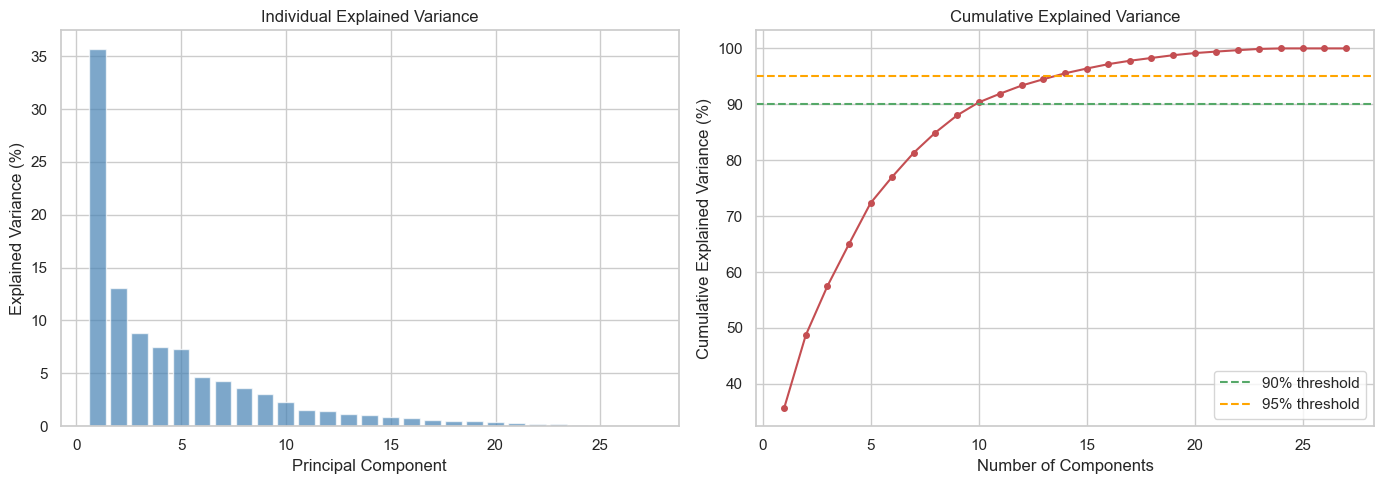


Số components để giải thích 90% variance: 10
Số components để giải thích 95% variance: 14


In [83]:
# Tính cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_ * 100, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Individual Explained Variance')

# Cumulative variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
         'ro-', markersize=4)
ax2.axhline(y=90, color='g', linestyle='--', label='90% threshold')
ax2.axhline(y=95, color='orange', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "pca_scree_plot.png", dpi=150)
plt.show()

# Tìm số components cần thiết
n_90 = np.argmax(cumulative_variance >= 90) + 1
n_95 = np.argmax(cumulative_variance >= 95) + 1
print(f"\nSố components để giải thích 90% variance: {n_90}")
print(f"Số components để giải thích 95% variance: {n_95}")

### 9.4. PCA với số components tối ưu

In [84]:
# PCA với 95% variance
pca_95 = PCA(n_components=0.95)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

print("PCA với 95% variance:")
print("="*50)
print(f"  Số components: {pca_95.n_components_}")
print(f"  Giải thích được: {sum(pca_95.explained_variance_ratio_)*100:.2f}%")
print(f"  Shape trước PCA: {X_train_scaled.shape}")
print(f"  Shape sau PCA: {X_train_pca.shape}")
print(f"  Giảm: {X_train_scaled.shape[1] - pca_95.n_components_} features")

PCA với 95% variance:
  Số components: 14
  Giải thích được: 95.55%
  Shape trước PCA: (202944, 27)
  Shape sau PCA: (202944, 14)
  Giảm: 13 features


## 10. Xử lý mất cân bằng dữ liệu (Imbalanced Data)

### 10.1. Giới thiệu về mất cân bằng dữ liệu

In [85]:
print("""
XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU (IMBALANCED DATA)
============================================

Vấn đề: Dataset có tỷ lệ 86:14 (non-diabetic : diabetic)

Các phương pháp xử lý:

1. Class Weighting (Đang sử dụng)
   - Logistic Regression: class_weight='balanced'
   - Random Forest: class_weight='balanced'
   - XGBoost: scale_pos_weight

2. SMOTE (Synthetic Minority Over-sampling Technique)
   - Tạo mẫu synthetic cho lớp thiểu số
   - Minh họa bên dưới

3. Undersampling
   - Giảm mẫu lớp đa số

4. Combination (SMOTE + ENN, SMOTE + Tomek)
""")


XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU (IMBALANCED DATA)

Vấn đề: Dataset có tỷ lệ 86:14 (non-diabetic : diabetic)

Các phương pháp xử lý:

1. Class Weighting (Đang sử dụng)
   - Logistic Regression: class_weight='balanced'
   - Random Forest: class_weight='balanced'
   - XGBoost: scale_pos_weight

2. SMOTE (Synthetic Minority Over-sampling Technique)
   - Tạo mẫu synthetic cho lớp thiểu số
   - Minh họa bên dưới

3. Undersampling
   - Giảm mẫu lớp đa số

4. Combination (SMOTE + ENN, SMOTE + Tomek)



### 10.2. Tính class weight

In [86]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

print("CLASS DISTRIBUTION:")
print("="*50)
print(f"  Negative (0 - Non-diabetic): {negative_count:,}")
print(f"  Positive (1 - Diabetic): {positive_count:,}")
print(f"  Imbalance ratio: {scale_pos_weight:.2f}:1")
print(f"  scale_pos_weight cho XGBoost: {scale_pos_weight:.4f}")

CLASS DISTRIBUTION:
  Negative (0 - Non-diabetic): 174,667
  Positive (1 - Diabetic): 28,277
  Imbalance ratio: 6.18:1
  scale_pos_weight cho XGBoost: 6.1770


### 10.3. Minh họa SMOTE (không chạy, chỉ giới thiệu)

In [87]:
# Ví dụ SMOTE (không thực thi, chỉ minh họa)
print("""
# Để sử dụng SMOTE:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Sau SMOTE:
# - negative_count sẽ tăng lên
# - positive_count giữ nguyên hoặc tăng theo tỷ lệ
# - Dataset sẽ cân bằng hơn
""")

print("⚠️ LƯU Ý: SMOTE chỉ nên áp dụng trên train set, không áp dụng trên test set!")


# Để sử dụng SMOTE:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Sau SMOTE:
# - negative_count sẽ tăng lên
# - positive_count giữ nguyên hoặc tăng theo tỷ lệ
# - Dataset sẽ cân bằng hơn

⚠️ LƯU Ý: SMOTE chỉ nên áp dụng trên train set, không áp dụng trên test set!


## 11. Cross-Validation

### 11.1. Giới thiệu Cross-Validation

In [88]:
print("""
CROSS-VALIDATION
================

K-Fold Cross Validation:
- Chia dữ liệu thành k phần (folds)
- Huấn luyện k lần, mỗi lần dùng 1 fold làm validation
- Kết quả trung bình cho đánh giá ổn định hơn

Trong hệ thống sử dụng:
- 5-Fold Cross Validation
- Stratified (đảm bảo tỷ lệ lớp trong mỗi fold)
""")


CROSS-VALIDATION

K-Fold Cross Validation:
- Chia dữ liệu thành k phần (folds)
- Huấn luyện k lần, mỗi lần dùng 1 fold làm validation
- Kết quả trung bình cho đánh giá ổn định hơn

Trong hệ thống sử dụng:
- 5-Fold Cross Validation
- Stratified (đảm bảo tỷ lệ lớp trong mỗi fold)



### 11.2. Cross-Validation cho XGBoost

In [89]:
# Cross-validation cho XGBoost
print("CROSS-VALIDATION VỚI XGBOOST (5-Fold)")
print("="*50)

# Tạo pipeline tạm thời cho cross-validation
xgb_temp = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=50,  # Giảm để nhanh hơn
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ))
])

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb_temp, X_train_fe, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"F1 Scores per fold: {cv_scores.round(4)}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

CROSS-VALIDATION VỚI XGBOOST (5-Fold)


F1 Scores per fold: [0.4329 0.4363 0.4412 0.4373 0.4389]
Mean F1: 0.4373 (+/- 0.0055)


## 12. Xây dựng Pipeline và Huấn luyện Mô hình

### 12.1. Cấu hình 3 mô hình

In [90]:
# Logistic Regression - Baseline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ))
])

# Random Forest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=160,
        max_depth=16,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=180,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

print("Đã khởi tạo 3 mô hình:")
print("  1. Logistic Regression (baseline)")
print("  2. Random Forest (ensemble)")
print("  3. XGBoost (gradient boosting)")

Đã khởi tạo 3 mô hình:
  1. Logistic Regression (baseline)
  2. Random Forest (ensemble)
  3. XGBoost (gradient boosting)


### 12.2. Huấn luyện mô hình

In [91]:
models = {
    "logistic_regression": logistic_model,
    "random_forest": rf_model,
    "xgboost": xgb_model
}

print("HUẤN LUYỆN CÁC MÔ HÌNH")
print("="*50)

start = time.time()

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    model.fit(X_train_fe, y_train)
    print(f"  ✓ Hoàn thành!")

total_time = time.time() - start
print(f"\nTổng thời gian huấn luyện: {total_time:.2f} giây")

HUẤN LUYỆN CÁC MÔ HÌNH
Đang huấn luyện logistic_regression...
  ✓ Hoàn thành!
Đang huấn luyện random_forest...
  ✓ Hoàn thành!
Đang huấn luyện xgboost...
  ✓ Hoàn thành!

Tổng thời gian huấn luyện: 74.65 giây


## 13. Đánh giá Mô hình

### 13.1. Định nghĩa hàm đánh giá

In [92]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist()
    }

    return metrics

### 13.2. Đánh giá tất cả các mô hình

In [93]:
all_metrics = {}

for name, model in models.items():
    all_metrics[name] = evaluate_model(model, X_test_fe, y_test, name)

# Hiển thị kết quả
comparison_df = pd.DataFrame([
    {"Model": name, **m}
    for name, m in all_metrics.items()
])[["Model", "accuracy", "precision", "recall", "f1", "roc_auc"]]

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("="*70)
display(comparison_df)

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH


,Model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.732320,0.312442,0.767294,0.444062,0.820767
1,random_forest,0.784926,0.350873,0.639553,0.453142,0.818215
2,xgboost,0.720967,0.306084,0.791342,0.441428,0.826576


### 13.3. Classification Reports

In [94]:
print("CLASSIFICATION REPORTS")
print("="*70)

for name, model in models.items():
    y_pred = model.predict(X_test_fe)
    print(f"\n{name.replace('_', ' ').title()}:")
    print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"]))

CLASSIFICATION REPORTS

Logistic Regression:
              precision    recall  f1-score   support

Non-diabetic       0.95      0.73      0.82     43667
    Diabetic       0.31      0.77      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736


Random Forest:
              precision    recall  f1-score   support

Non-diabetic       0.93      0.81      0.87     43667
    Diabetic       0.35      0.64      0.45      7069

    accuracy                           0.78     50736
   macro avg       0.64      0.72      0.66     50736
weighted avg       0.85      0.78      0.81     50736


Xgboost:
              precision    recall  f1-score   support

Non-diabetic       0.95      0.71      0.81     43667
    Diabetic       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
wei

### 13.4. Biểu đồ so sánh

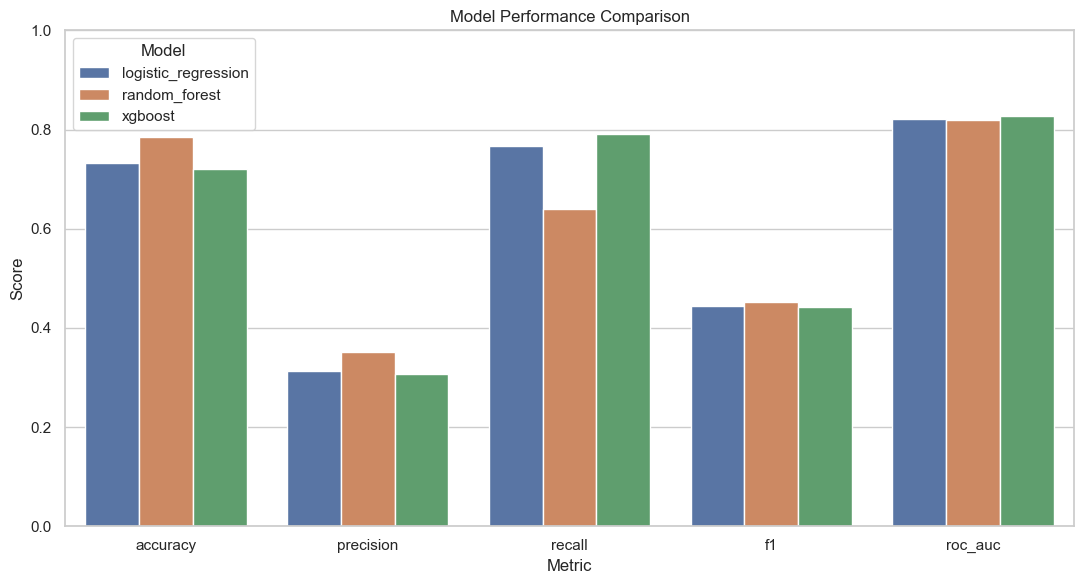

In [95]:
# Grouped Bar Metrics
metrics_long = comparison_df.melt(
    id_vars="Model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=metrics_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "grouped_bar_metrics.png", dpi=150)
plt.show()

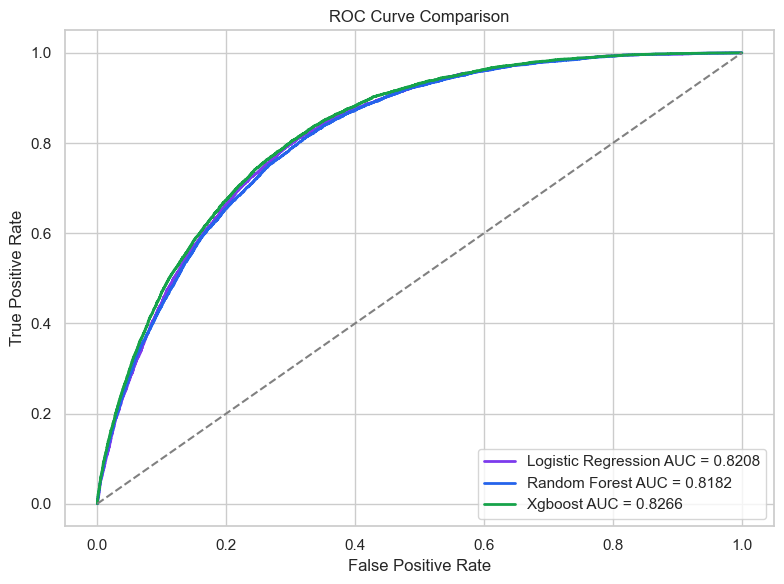

In [96]:
# ROC Curve
colors = {"logistic_regression": "#7c3aed", "random_forest": "#2563eb", "xgboost": "#16a34a"}

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_fe)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name.replace('_', ' ').title()} AUC = {roc_auc:.4f}",
             color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "roc_curve_comparison.png", dpi=150)
plt.show()

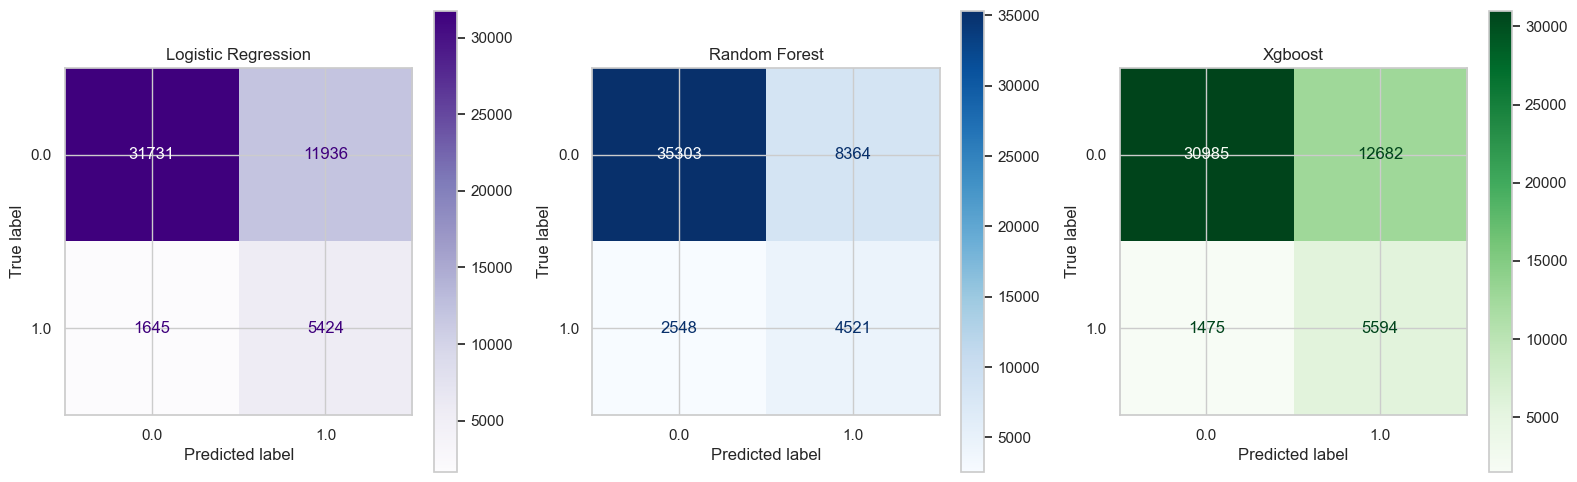

In [97]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cmaps = {"logistic_regression": "Purples", "random_forest": "Blues", "xgboost": "Greens"}

for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test_fe, y_test, ax=ax, cmap=cmaps[name])
    ax.set_title(name.replace("_", " ").title())

plt.tight_layout()
plt.savefig(ROOT / "reports" / "figures" / "confusion_matrix.png", dpi=150)
plt.show()

## 14. Lưu artifacts

### 14.1. Lưu dữ liệu sau tiền xử lý

In [99]:
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

X_train_fe.to_csv(PROCESSED_DIR / "X_train.csv", index=False)
X_test_fe.to_csv(PROCESSED_DIR / "X_test.csv", index=False)
y_train.to_frame(name=target_col).to_csv(PROCESSED_DIR / "y_train.csv", index=False)
y_test.to_frame(name=target_col).to_csv(PROCESSED_DIR / "y_test.csv", index=False)

print("Đã lưu dữ liệu sau tiền xử lý vào data/processed:")
print(f"  - X_train.csv: {X_train_fe.shape}")
print(f"  - X_test.csv: {X_test_fe.shape}")
print(f"  - y_train.csv: ({y_train.shape[0]}, 1)")
print(f"  - y_test.csv: ({y_test.shape[0]}, 1)")

Đã lưu dữ liệu sau tiền xử lý vào data/processed:
  - X_train.csv: (202944, 24)
  - X_test.csv: (50736, 24)
  - y_train.csv: (202944, 1)
  - y_test.csv: (50736, 1)


### 14.2. Lưu model và metrics

In [ ]:
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "logistic_regression": MODELS_DIR / "logistic_regression.joblib",
    "random_forest": MODELS_DIR / "random_forest.joblib",
    "xgboost": MODELS_DIR / "xgboost.joblib"
}

for name, model in models.items():
    joblib.dump(model, MODEL_PATHS[name])

joblib.dump(feature_columns, MODELS_DIR / "feature_columns.joblib")
print("Đã lưu models:")
for name, path in MODEL_PATHS.items():
    print(f"  - {path.name}")

Đã lưu models:
  - logistic_regression.joblib
  - random_forest.joblib
  - xgboost.joblib


In [ ]:
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

with open(REPORTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2, ensure_ascii=False)

print("Đã lưu metrics.json")

Đã lưu metrics.json


## 15. Tổng kết các kỹ thuật tiền xử lý

### 15.1. Sơ đồ các bước tiền xử lý

In [ ]:
print("""
TỔNG KẾT CÁC KỸ THUẬT TIỀN XỬ LÝ DỮ LIỆU
==========================================

┌─────────────────────────────────────────────────────────────┐
│ 1. TÍCH HỢP DỮ LIỆU (Data Integration)                    │
│    - Load dữ liệu từ file CSV                             │
│    - Kết hợp các nguồn dữ liệu (nếu có)                   │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 2. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)                       │
│    - Thống kê mô tả                                       │
│    - Phân phối các biến                                   │
│    - Ma trận tương quan                                    │
│    - Phân tích biến mục tiêu                               │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 3. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU                            │
│    - Missing values                                       │
│    - Giá trị không hợp lệ                                  │
│    - Outliers                                             │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 4. LẤY MẪU (Sampling)                                     │
│    - Stratified Sampling với stratify=y                   │
│    - Đảm bảo tỷ lệ lớp nhất quán                          │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 5. TẠO MỚI THUỘC TÍNH (Feature Engineering)              │
│    - BMI_category: Rời rạc hóa BMI thành 4 nhóm           │
│    - comorbidity_score: Tổng hợp 5 tình trạng bệnh        │
│    - healthy_lifestyle: Điểm lối sống lành mạnh            │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 6. CHUYỂN ĐỔI THUỘC TÍNH (Attribute Transformation)       │
│    - StandardScaler: Chuẩn hóa biến liên tục             │
│    - OneHotEncoder: Mã hóa biến phân loại                 │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 7. LỰA CHỌN THUỘC TÍNH (Feature Selection)                │
│    - SelectKBest với ANOVA F-test                          │
│    - Mutual Information                                    │
│    - Xác định feature quan trọng                          │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 8. GIẢM SỐ CHIỀU (Dimensionality Reduction)               │
│    - PCA (95% variance → 24 components)                    │
│    - Giải thích phương sai của từng thành phần             │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 9. XỬ LÝ MẤT CÂN BẰNG (Imbalanced Data)                    │
│    - class_weight='balanced' cho LR và RF                  │
│    - scale_pos_weight cho XGBoost                           │
│    - Có thể dùng SMOTE (minh họa)                          │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 10. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH                         │
│     - Cross-Validation (5-Fold Stratified)                 │
│     - Huấn luyện 3 mô hình                                  │
│     - Đánh giá bằng các metrics                             │
└─────────────────────────────────────────────────────────────┘
""")


TỔNG KẾT CÁC KỸ THUẬT TIỀN XỬ LÝ DỮ LIỆU

┌─────────────────────────────────────────────────────────────┐
│ 1. TÍCH HỢP DỮ LIỆU (Data Integration)                    │
│    - Load dữ liệu từ file CSV                             │
│    - Kết hợp các nguồn dữ liệu (nếu có)                   │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 2. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)                       │
│    - Thống kê mô tả                                       │
│    - Phân phối các biến                                   │
│    - Ma trận tương quan                                    │
│    - Phân tích biến mục tiêu                               │
└─────────────────────────────────────────────────────────────┘
                          ↓
┌─────────────────────────────────────────────────────────────┐
│ 3. KIỂM TRA CHẤT LƯỢNG DỮ LIỆU                            │
│    - Missing values

### 15.2. Kết quả cuối cùng

In [ ]:
print("KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG")
print("="*70)
display(comparison_df)

best_model = comparison_df.loc[comparison_df['roc_auc'].idxmax(), 'Model']
best_f1 = comparison_df.loc[comparison_df['f1'].idxmax(), 'Model']

print(f"\n🏆 Mô hình tốt nhất theo ROC-AUC: {best_model}")
print(f"🏆 Mô hình tốt nhất theo F1-Score: {best_f1}")

print("\n" + "="*70)
print("NOTEBOOK HOÀN THÀNH!")
print("="*70)
print("\nCác file đã được lưu:")
print(f"  - Dữ liệu: data/processed/")
print(f"  - Models: models/")
print(f"  - Metrics: reports/metrics.json")
print(f"  - Hình ảnh: reports/figures/")

KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG


,Model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.732320,0.312442,0.767294,0.444062,0.820767
1,random_forest,0.784926,0.350873,0.639553,0.453142,0.818215
2,xgboost,0.720967,0.306084,0.791342,0.441428,0.826576



🏆 Mô hình tốt nhất theo ROC-AUC: xgboost
🏆 Mô hình tốt nhất theo F1-Score: random_forest

NOTEBOOK HOÀN THÀNH!

Các file đã được lưu:
  - Dữ liệu: data/processed/
  - Models: models/
  - Metrics: reports/metrics.json
  - Hình ảnh: reports/figures/
